In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pybaselines import Baseline, utils
import os 
import glob
from galvani import BioLogic as BL
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio # For Plotly themes 

# Function for reading files

In [2]:
def read_data(file_name):
    legend_temp = []
    data_line_temp = []
    time_stamp_temp = []
    data_storing = False
    print(f"Reading file: {file_name}")
    with open(file_name, 'r') as file:
        for line in file:
            if 'q(A-1)' in line:
                data_storing = True
                continue
            if 'Comment' in line:
                legend_temp = line.split()[4]
            if 'Date' in line:
                time_stamp_temp = line.split()[2] 
            if data_storing:
                data_line_temp.append(line.strip())
    df_temp= pd.DataFrame([line.split() for line in data_line_temp])
    df_temp= df_temp.astype(float)

    return legend_temp, time_stamp_temp ,df_temp

    

# Read all the files

In [3]:
os.chdir(r'/workspaces/codespaces-jupyter/data/Test_data/20240604_2503-SKJB_6MECDEC_100volHFE')
file_list = glob.glob('*_1_*.dat')

legend = {} #Dictionary for storing the comments from experiment data files to be used as legends later
time_stamp = {} #Dictionary to store the time of file creation
key = 0
file_dictionary = {} # Dictionary for storing all the pandas data file 

# Read all the files data from the directory and also the comments and file generation time in seperate pd dataframe

for data_file in file_list:
    key += 1
    legend[key], time_stamp[key], file_dictionary[key] = read_data(data_file)

    
print('Number of files:',key)

Reading file: 6MECDEC_100volHFE_1_00013.dat
Reading file: 6MECDEC_100volHFE_1_00155.dat
Reading file: 6MECDEC_100volHFE_1_00098.dat
Reading file: 6MECDEC_100volHFE_1_00323.dat
Reading file: 6MECDEC_100volHFE_1_00426.dat
Reading file: 6MECDEC_100volHFE_1_00178.dat
Reading file: 6MECDEC_100volHFE_1_00052.dat
Reading file: 6MECDEC_100volHFE_1_00209.dat
Reading file: 6MECDEC_100volHFE_1_00413.dat
Reading file: 6MECDEC_100volHFE_1_00297.dat
Reading file: 6MECDEC_100volHFE_1_00089.dat
Reading file: 6MECDEC_100volHFE_1_00192.dat
Reading file: 6MECDEC_100volHFE_1_00338.dat
Reading file: 6MECDEC_100volHFE_1_00373.dat
Reading file: 6MECDEC_100volHFE_1_00078.dat
Reading file: 6MECDEC_100volHFE_1_00445.dat
Reading file: 6MECDEC_100volHFE_1_00135.dat
Reading file: 6MECDEC_100volHFE_1_00206.dat
Reading file: 6MECDEC_100volHFE_1_00107.dat
Reading file: 6MECDEC_100volHFE_1_00355.dat
Reading file: 6MECDEC_100volHFE_1_00396.dat
Reading file: 6MECDEC_100volHFE_1_00147.dat
Reading file: 6MECDEC_100volHFE_

In [4]:
pio.templates.default = "simple_white"
fig = go.Figure()
for key in file_dictionary:
    X_data = file_dictionary[key].iloc[:,0]
    Y_data = file_dictionary[key].iloc[:,1]
    fig.add_trace(go.Scatter(x = X_data, y = Y_data))



fig.show()

# For Baseline correction (manually select the first long exposure file)

In [ ]:

background_file = glob.glob('*_Al_WAXS.dat')
for input in background_file:
    a1,a2,background = read_data(input)


Reading file: beckground_with_Al_WAXS.dat


# Creating the background 

[0.00613412 0.00620367 0.00627275 ... 0.00304034 0.00304355 0.00304703]


Text(0, 0.5, 'Intensity (a.u.)')

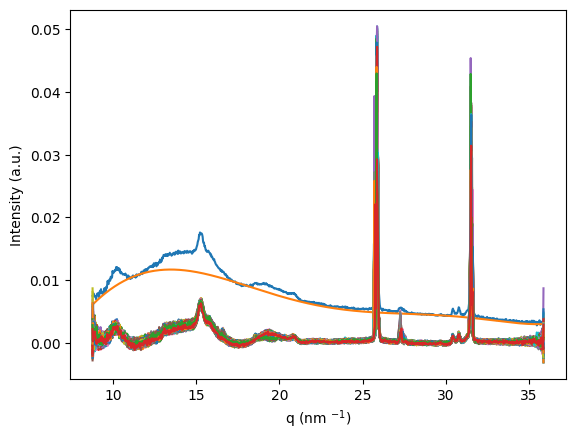

In [ ]:
X_data = []
Y_data = []

# Create a average over the first three data files 

for files in range(1,4):
    if files == 1:
        X_data = 10*file_dictionary[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        Y_data = file_dictionary[files].iloc[:,1]
    else:
        x = 10*file_dictionary[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        y = file_dictionary[files].iloc[:,1]
        X_data += x
        Y_data += y

for entries in range(len(X_data)):
    X_data[entries] = X_data[entries]/3
    Y_data[entries] = Y_data[entries]/3

baseline_filter = Baseline(x_data = X_data)
baseline = baseline_filter.modpoly(Y_data, poly_order= 6)[0]
print(baseline)
modified_Y = Y_data-baseline
plt.plot(X_data, Y_data)
plt.plot(X_data, baseline)
plt.plot(X_data, modified_Y)

# Create new file dictionary with corrected spectra
corrected_waxs_files = {}
for ikey in file_dictionary:
    X_data = 10*file_dictionary[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[ikey].iloc[:,1]
    modified_Y = Y_data - baseline
    plt.plot(X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    corrected_waxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')


In [ ]:
# This is just to check the file updated or not